In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
import random
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, LSTM, Bidirectional, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150

PREP = '/kaggle/input/notebooks/hongsh184/test122/preprocessed/'
MODELS_MLP = '/kaggle/input/notebooks/hongsh184/test1222/models/'
MODELS_BILSTM = '/kaggle/input/notebooks/hongsh184/test122222/models/'
VIS_DIR = Path('/kaggle/working/visualizations/')
VIS_DIR.mkdir(exist_ok=True)

mlp_model = tf.keras.models.load_model(MODELS_MLP + 'TUN2_u64_p90_nodrop.keras')
mlp_threshold = float(np.load(MODELS_MLP + 'TUN2_u64_p90_nodrop_threshold.npy'))
bilstm_model = tf.keras.models.load_model(MODELS_BILSTM + 'bilstm_tanh_base.keras')
bilstm_threshold = float(np.load(MODELS_BILSTM + 'bilstm_tanh_base_threshold.npy'))

print(f"MLP threshold: {mlp_threshold:.6f}")
print(f"Bi-LSTM threshold: {bilstm_threshold:.6f}")
print("Setup complete")

2026-04-09 06:58:07.967033: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775717888.225257      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775717888.302928      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775717888.938578      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775717888.938619      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775717888.938622      17 computation_placer.cc:177] computation placer alr

MLP threshold: 0.000150
Bi-LSTM threshold: 0.000907
Setup complete


[VIS 1] Loss Curve...
X_train_w5: (20000, 5, 78)
X_train_w20: (20000, 20, 78)
MLP training...
MLP done: 100 epochs
Bi-LSTM training...
Bi-LSTM done: 100 epochs


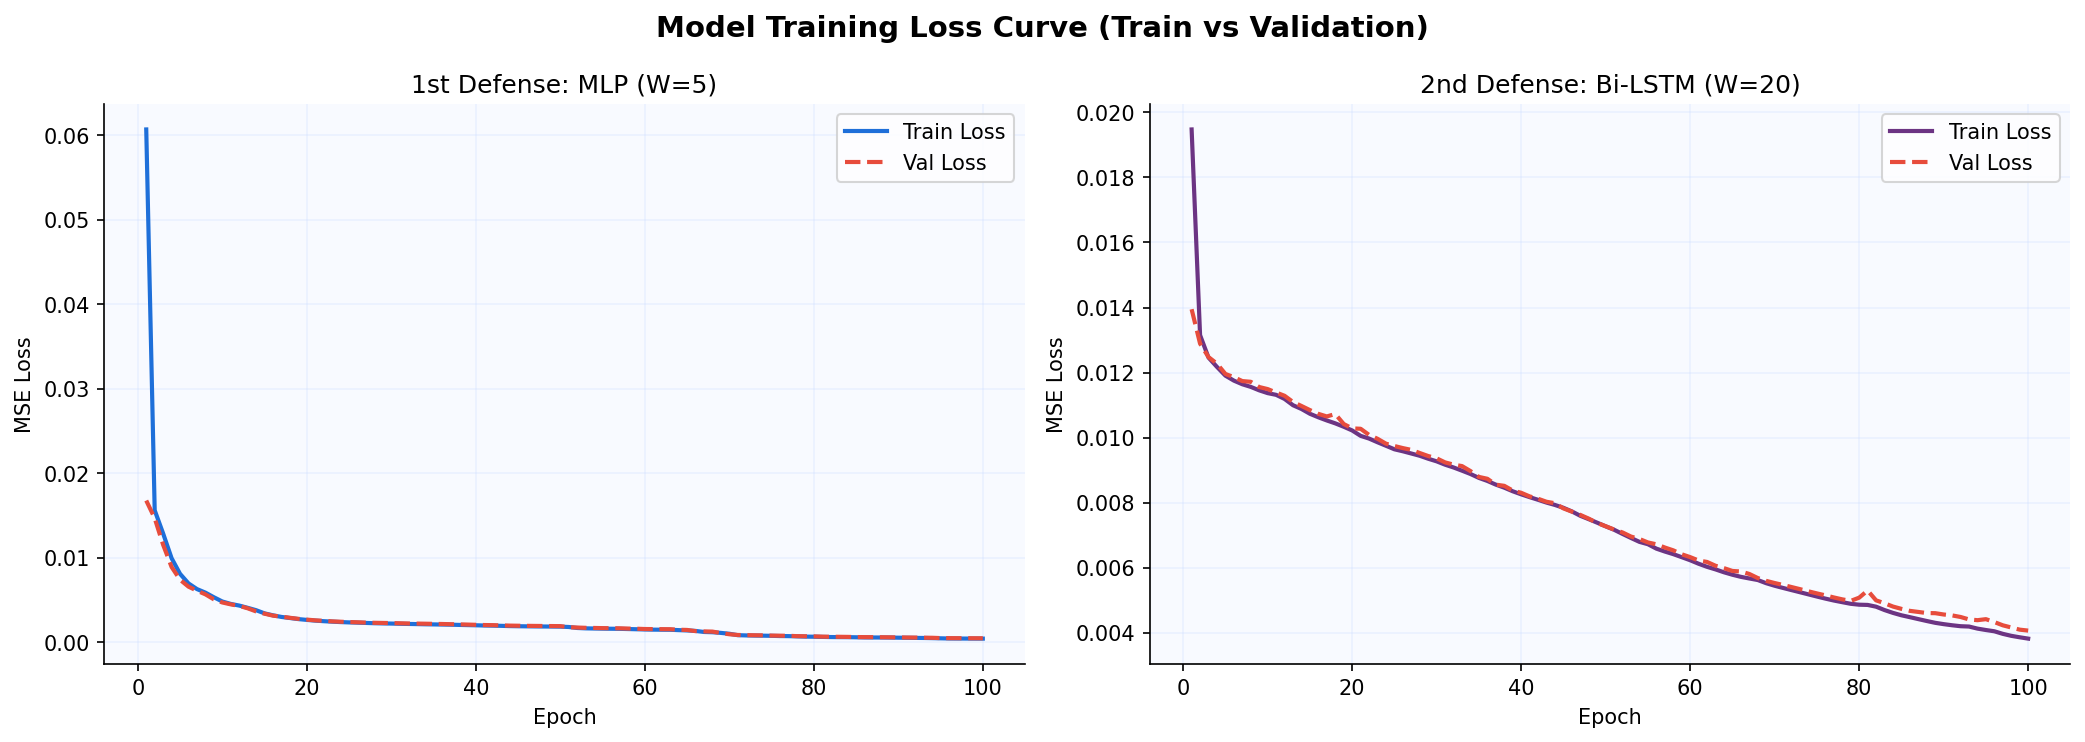

VIS 1 done


In [2]:
print("[VIS 1] Loss Curve...")

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

SAMPLE_SIZE = 20000
TIMESTEPS_W5 = 5
TIMESTEPS_W20 = 20
FEATURES = 78

X_train_w5 = np.load(PREP + 'X_train_w5.npy')[:SAMPLE_SIZE]
X_train_w20 = np.load(PREP + 'X_train_w20.npy')[:SAMPLE_SIZE]
print(f"X_train_w5: {X_train_w5.shape}")
print(f"X_train_w20: {X_train_w20.shape}")

es_vis = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("MLP training...")
inp = Input(shape=(TIMESTEPS_W5, FEATURES))
x = Flatten()(inp)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
out = Dense(TIMESTEPS_W5 * FEATURES, activation='sigmoid')(x)
out = Reshape((TIMESTEPS_W5, FEATURES))(out)
mlp_vis = Model(inp, out)
mlp_vis.compile(optimizer='adam', loss='mse')

mlp_hist = mlp_vis.fit(
    X_train_w5, X_train_w5,
    epochs=100, batch_size=256,
    validation_split=0.1,
    callbacks=[es_vis], verbose=0
)
print(f"MLP done: {len(mlp_hist.history['loss'])} epochs")

print("Bi-LSTM training...")
inp2 = Input(shape=(TIMESTEPS_W20, FEATURES))
enc = Bidirectional(LSTM(64, activation='tanh', return_sequences=False))(inp2)
rep = RepeatVector(TIMESTEPS_W20)(enc)
dec = Bidirectional(LSTM(64, activation='tanh', return_sequences=True))(rep)
out2 = TimeDistributed(Dense(FEATURES))(dec)
bilstm_vis = Model(inp2, out2)
bilstm_vis.compile(optimizer='adam', loss='mse')

bilstm_hist = bilstm_vis.fit(
    X_train_w20, X_train_w20,
    epochs=100, batch_size=256,
    validation_split=0.1,
    callbacks=[es_vis], verbose=0
)
print(f"Bi-LSTM done: {len(bilstm_hist.history['loss'])} epochs")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training Loss Curve (Train vs Validation)', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('#F8FAFF')
epochs_mlp = range(1, len(mlp_hist.history['loss']) + 1)
ax.plot(epochs_mlp, mlp_hist.history['loss'], color='#1E6FD9', linewidth=2, label='Train Loss')
ax.plot(epochs_mlp, mlp_hist.history['val_loss'], color='#E74C3C', linewidth=2, label='Val Loss', linestyle='--')
ax.set_title('1st Defense: MLP (W=5)', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.set_facecolor('#F8FAFF')
epochs_bi = range(1, len(bilstm_hist.history['loss']) + 1)
ax.plot(epochs_bi, bilstm_hist.history['loss'], color='#6C3483', linewidth=2, label='Train Loss')
ax.plot(epochs_bi, bilstm_hist.history['val_loss'], color='#E74C3C', linewidth=2, label='Val Loss', linestyle='--')
ax.set_title('2nd Defense: Bi-LSTM (W=20)', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(VIS_DIR / 'vis1_loss_curve.png', bbox_inches='tight', facecolor='white')
plt.show()
print("VIS 1 done")

[VIS 2] KDE MSE Distribution...
Data loaded


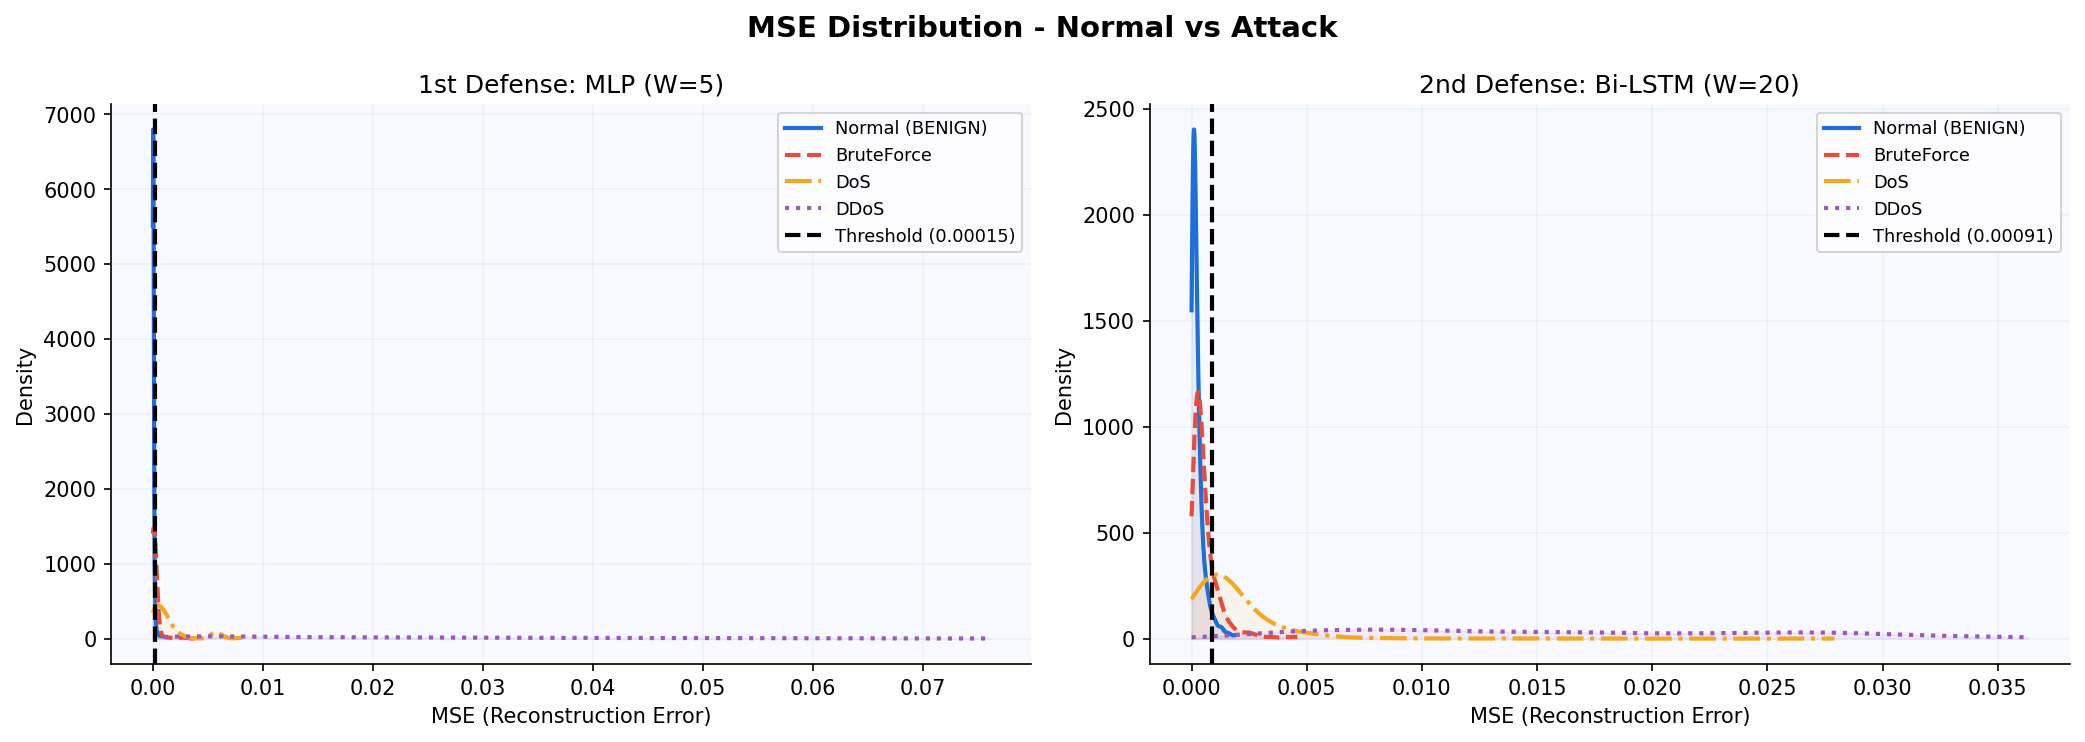

VIS 2 done


In [3]:
print("[VIS 2] KDE MSE Distribution...")

X_te_tue_w5 = np.load(PREP + 'X_te_tue_w5.npy')
X_te_wed_w5 = np.load(PREP + 'X_te_wed_w5.npy')
X_te_fri_w5 = np.load(PREP + 'X_te_fri_w5.npy')
y_te_tue_w5 = np.load(PREP + 'y_te_tue_w5.npy', allow_pickle=True)
y_te_wed_w5 = np.load(PREP + 'y_te_wed_w5.npy', allow_pickle=True)
y_te_fri_w5 = np.load(PREP + 'y_te_fri_w5.npy', allow_pickle=True)

X_te_tue_w20 = np.load(PREP + 'X_te_tue_w20.npy')
X_te_wed_w20 = np.load(PREP + 'X_te_wed_w20.npy')
X_te_fri_w20 = np.load(PREP + 'X_te_fri_w20.npy')
y_te_tue_w20 = np.load(PREP + 'y_te_tue_w20.npy', allow_pickle=True)
y_te_wed_w20 = np.load(PREP + 'y_te_wed_w20.npy', allow_pickle=True)
y_te_fri_w20 = np.load(PREP + 'y_te_fri_w20.npy', allow_pickle=True)

X_val_w5 = np.load(PREP + 'X_val_w5.npy')
X_val_w20 = np.load(PREP + 'X_val_w20.npy')
print("Data loaded")

def get_mse(model, X):
    recon = model.predict(X, verbose=0, batch_size=256)
    return np.mean(np.power(X - recon, 2), axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MSE Distribution - Normal vs Attack', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('#F8FAFF')

mse_normal = get_mse(mlp_model, X_val_w5[:5000])
mse_bf = get_mse(mlp_model, X_te_tue_w5[y_te_tue_w5 != 'BENIGN'][:2000])
mse_dos = get_mse(mlp_model, X_te_wed_w5[y_te_wed_w5 != 'BENIGN'][:2000])
mse_dds = get_mse(mlp_model, X_te_fri_w5[y_te_fri_w5 != 'BENIGN'][:2000])

for mse, label, color, ls in [
    (mse_normal, 'Normal (BENIGN)', '#1E6FD9', '-'),
    (mse_bf, 'BruteForce', '#E74C3C', '--'),
    (mse_dos, 'DoS', '#F5A623', '-.'),
    (mse_dds, 'DDoS', '#9B59B6', ':'),
]:
    clip_val = np.percentile(mse, 99)
    try:
        kde = gaussian_kde(mse)
    except np.linalg.LinAlgError:
        kde = gaussian_kde(mse + np.random.normal(0, 1e-8, len(mse)))
    x_range = np.linspace(0, clip_val, 300)
    ax.plot(x_range, kde(x_range), label=label, color=color, linewidth=2, linestyle=ls)
    ax.fill_between(x_range, kde(x_range), alpha=0.08, color=color)

ax.axvline(mlp_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({mlp_threshold:.5f})')
ax.set_title('1st Defense: MLP (W=5)', fontsize=12)
ax.set_xlabel('MSE (Reconstruction Error)')
ax.set_ylabel('Density')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.set_facecolor('#F8FAFF')

mse_normal20 = get_mse(bilstm_model, X_val_w20[:2000])
mse_bf20 = get_mse(bilstm_model, X_te_tue_w20[y_te_tue_w20 != 'BENIGN'][:2000])
mse_dos20 = get_mse(bilstm_model, X_te_wed_w20[y_te_wed_w20 != 'BENIGN'][:2000])
mse_dds20 = get_mse(bilstm_model, X_te_fri_w20[y_te_fri_w20 != 'BENIGN'][:2000])

for mse, label, color, ls in [
    (mse_normal20, 'Normal (BENIGN)', '#1E6FD9', '-'),
    (mse_bf20, 'BruteForce', '#E74C3C', '--'),
    (mse_dos20, 'DoS', '#F5A623', '-.'),
    (mse_dds20, 'DDoS', '#9B59B6', ':'),
]:
    clip_val = np.percentile(mse, 99)
    try:
        kde = gaussian_kde(mse)
    except np.linalg.LinAlgError:
        kde = gaussian_kde(mse + np.random.normal(0, 1e-8, len(mse)))
    x_range = np.linspace(0, clip_val, 300)
    ax.plot(x_range, kde(x_range), label=label, color=color, linewidth=2, linestyle=ls)
    ax.fill_between(x_range, kde(x_range), alpha=0.08, color=color)

ax.axvline(bilstm_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({bilstm_threshold:.5f})')
ax.set_title('2nd Defense: Bi-LSTM (W=20)', fontsize=12)
ax.set_xlabel('MSE (Reconstruction Error)')
ax.set_ylabel('Density')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(VIS_DIR / 'vis2_kde_mse.png', bbox_inches='tight', facecolor='white')
plt.show()
print("VIS 2 done")